# Market Feasibility Research: Korean Traditional Dessert
## 韓式傳統甜點市場可行性研究

> **研究問題**：如何用數據而非直覺，評估개성주악（開城油蜜果）在首爾的開店可行性？
>
> **作者**：Anita Wu｜2026 年 4 月

---

### 研究架構
```
Stage 1：供給面分析  →  首爾 50 間標竿店品項評分
Stage 2：需求面驗證  →  台北・東京・溫哥華 850 則評論跨店關鍵字分析
Stage 3：交叉比對    →  개성주악 是否符合海外消費者真實偏好？
```

In [1]:
# ── 套件載入 ──────────────────────────────────────
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# 中文字體設定（Mac）
plt.rcParams['font.family'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 統一配色
COLORS = {
    'red':    '#C0392B',
    'dark':   '#2C3E50',
    'green':  '#27AE60',
    'orange': '#E67E22',
    'blue':   '#2980B9',
    'gray':   '#95A5A6',
    'light':  '#FAF6F1',
}
CITY_COLORS = {'台北': '#E74C3C', '東京': '#3498DB', '溫哥華': '#27AE60'}

print('✅ 環境設定完成')

✅ 環境設定完成


---
## Stage 1：Supply Analysis｜供給面分析
### 1-1 首爾標竿店品項評分矩陣

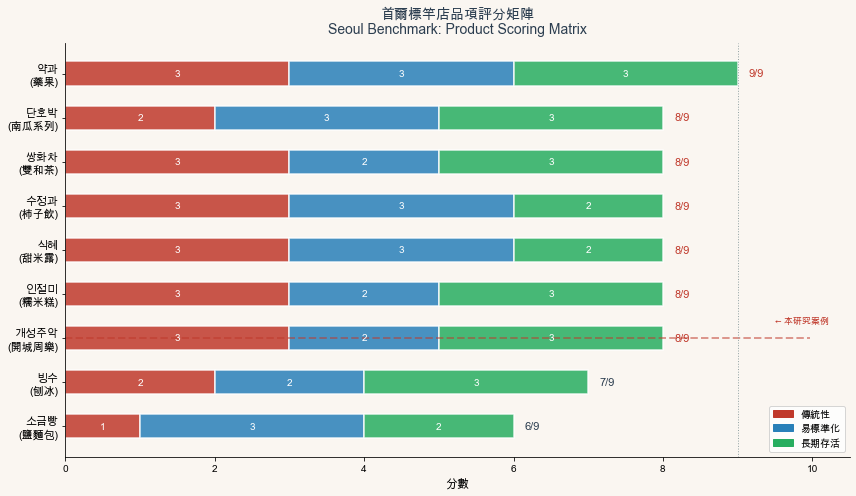

✅ 圖表 1 完成


In [14]:
# ── 品項評分數據 ───────────────────────────────────
# 三個維度各 0-3 分，總分 9 分
items_data = {
    '品項': [
        '개성주악\n(開城周樂)', '약과\n(藥果)', '빙수\n(刨冰)',
        '인절미\n(糯米糕)', '식혜\n(甜米露)', '수정과\n(柿子飲)',
        '쌍화차\n(雙和茶)', '단호박\n(南瓜系列)', '소금빵\n(鹽麵包)'
    ],
    '傳統性': [3, 3, 2, 3, 3, 3, 3, 2, 1],
    '易標準化': [2, 3, 2, 2, 3, 3, 2, 3, 3],
    '長期存活': [3, 3, 3, 3, 2, 2, 3, 3, 2],
}
df_items = pd.DataFrame(items_data)
df_items['總分'] = df_items['傳統性'] + df_items['易標準化'] + df_items['長期存活']
df_items = df_items.sort_values('總分', ascending=True)

# ── 視覺化：水平長條圖 ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#FAF6F1')
ax.set_facecolor('#FAF6F1')

dims = ['傳統性', '易標準化', '長期存活']
dim_colors = [COLORS['red'], COLORS['blue'], COLORS['green']]
bar_height = 0.55

for i, (_, row) in enumerate(df_items.iterrows()):
    left = 0
    for dim, color in zip(dims, dim_colors):
        ax.barh(i, row[dim], left=left, height=bar_height,
                color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
        if row[dim] > 0:
            ax.text(left + row[dim]/2, i, str(row[dim]),
                    ha='center', va='center', fontsize=10,
                    color='white', fontweight='bold')
        left += row[dim]
    # 總分標籤
    ax.text(left + 0.15, i, f"{int(row['總分'])}/9",
            va='center', fontsize=11, fontweight='bold',
            color=COLORS['red'] if row['總分'] >= 1 else COLORS['dark'])

# 標記개성주악
juak_idx = list(df_items['品項']).index('개성주악\n(開城周樂)')
ax.axhline(y=juak_idx, color=COLORS['red'], linewidth=2,
           linestyle='--', alpha=0.5, xmin=0, xmax=0.95)
ax.text(9.5, juak_idx + 0.35, '← 本研究案例', fontsize=9,
        color=COLORS['red'], style='italic')

ax.set_yticks(range(len(df_items)))
ax.set_yticklabels(df_items['品項'], fontsize=11)
ax.set_xlabel('分數', fontsize=12)
ax.set_xlim(0, 10.5)
ax.set_title('首爾標竿店品項評分矩陣\nSeoul Benchmark: Product Scoring Matrix',
             fontsize=14, fontweight='bold', pad=9, color=COLORS['dark'])
ax.axvline(x=9, color=COLORS['gray'], linewidth=1, linestyle=':')

# 圖例
legend = [mpatches.Patch(color=c, label=d) for d, c in zip(dims, dim_colors)]
ax.legend(handles=legend, loc='lower right', fontsize=10,
          framealpha=0.8, facecolor='white')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('chart_01_scoring_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='#FAF6F1')
plt.show()
print('✅ 圖表 1 完成')

### 1-2 개성주악 vs 약과 雷達圖比較

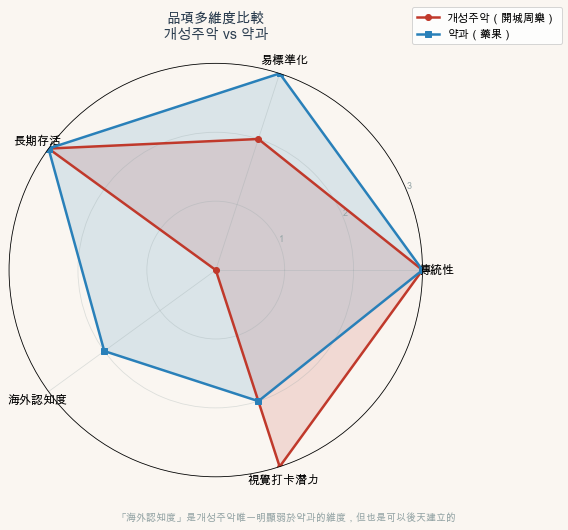

✅ 圖表 2 完成


In [13]:
# ── 雷達圖數據 ────────────────────────────────────
categories = ['傳統性', '易標準化', '長期存活', '海外認知度', '視覺打卡潛力']
N = len(categories)

# 各維度分數（0-3）
juak_scores  = [3, 2, 3, 0, 3]
yakgwa_scores = [3, 3, 3, 2, 2]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
juak_scores  += juak_scores[:1]
yakgwa_scores += yakgwa_scores[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#FAF6F1')
ax.set_facecolor('#FAF6F1')

# 畫線
ax.plot(angles, juak_scores, 'o-', linewidth=2.5,
        color=COLORS['red'], label='개성주악（開城周樂）')
ax.fill(angles, juak_scores, alpha=0.15, color=COLORS['red'])

ax.plot(angles, yakgwa_scores, 's-', linewidth=2.5,
        color=COLORS['blue'], label='약과（藥果）')
ax.fill(angles, yakgwa_scores, alpha=0.15, color=COLORS['blue'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 3)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['1', '2', '3'], fontsize=9, color=COLORS['gray'])
ax.grid(color=COLORS['gray'], alpha=0.3)

ax.set_title('品項多維度比較\n개성주악 vs 약과',
             fontsize=14, fontweight='bold', pad=25, color=COLORS['dark'])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          fontsize=11, framealpha=0.8, facecolor='white')

# 注釋
fig.text(0.5, 0.02,
         '「海外認知度」是개성주악唯一明顯弱於약과的維度，但也是可以後天建立的',
         ha='center', fontsize=10, color=COLORS['gray'], style='italic')

plt.tight_layout()
plt.savefig('chart_02_radar.png', dpi=150, bbox_inches='tight',
            facecolor='#FAF6F1')
plt.show()
print('✅ 圖表 2 完成')

---
## Stage 2：Demand Validation｜需求面驗證

### 方法論說明：為什麼用「跨店關鍵字」而不是「總次數」？

**問題**：初版直接加總關鍵字出現次數，東京「藥果」出現 28 次，看起來需求很高。

**發現**：28 次全部來自 ROZI coffee 一間店，代表這是**供給效應**（店家在賣），不是**需求效應**（消費者自發想要）。

```python
# ❌ 有偏差的版本
total = sum(review.count('약과') for review in all_reviews)  # → 28次，全來自同一間店

# ✅ 修正版本：統計出現在幾間不同的店
shop_counts = {}
for shop in df['店名'].unique():
    count = df[df['店名']==shop]['評論'].str.contains('약과').sum()
    if count > 0:
        shop_counts[shop] = count
cross_shop_num = len(shop_counts)  # → 藥果：東京只有 1 間店，不是廣泛需求
```

### 2-1 載入三城市評論數據

In [4]:
# ── 關鍵字定義 ────────────────────────────────────
KEYWORDS = {
    '藥果 약과':     ['약과', 'yakgwa', '薬菓'],
    '刨冰 빙수':     ['빙수', 'bingsu', 'shaved ice', 'かき氷'],
    '糖餅 호떡':     ['호떡', 'hotteok', '糖餅'],
    '年糕 떡':       ['떡', 'tteok', 'rice cake', '年糕'],
    '核桃糕 호두과자':['호두과자', 'walnut cake'],
    '黑芝麻':        ['흑임자', 'black sesame', '黒ごま'],
    '紅豆':          ['팥', 'red bean', 'あんこ'],
    '堅果':          ['견과류', 'nuts', 'ナッツ', 'walnut', 'peanut', 'almond'],
    '肉桂':          ['계피', 'cinnamon', 'シナモン'],
    '蜂蜜':          ['꿀', 'honey', 'はちみつ'],
    '不太甜':        ['甘すぎない', '甘さ控えめ', 'not too sweet',
                     'lightly sweet', '不太甜', '甜度剛好'],
    '酥脆':          ['サクサク', 'crispy', 'crunchy', '酥脆'],
    '軟糯':          ['しっとり', 'もちもち', 'chewy', '軟Q'],
    '韓國感':        ['韓国', 'Korean', 'authentic', '韓國'],
    '打卡拍照':      ['映え', 'instagram', 'cute', 'aesthetic', '打卡'],
    '回購推薦':      ['また来たい', 'recommend', 'will be back',
                     'must try', '推薦', '再來'],
}

def load_city_data(filepath):
    """載入城市 JSON 並整理成 DataFrame"""
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for d in data:
        rows.append({
            '店名': d.get('title', '') or '',
            '評分': d.get('stars', '') or '',
            '評論': d.get('text', '') or '',
            '翻譯': d.get('textTranslated', '') or '',
            '語言': d.get('originalLanguage', '') or '',
        })
    return pd.DataFrame(rows)

def cross_shop_analysis(df, keywords):
    """跨店關鍵字分析：統計每個關鍵字出現在幾間不同的店"""
    results = {}
    for label, words in keywords.items():
        shop_counts = {}
        for shop in df['店名'].unique():
            s = df[df['店名'] == shop]
            txt = ' '.join([
                (r or '') + ' ' + (t or '')
                for r, t in zip(s['評論'], s['翻譯'])
            ]).lower()
            count = sum(txt.count(w.lower()) for w in words)
            if count > 0:
                shop_counts[shop] = count
        results[label] = {
            'shop_num': len(shop_counts),
            'total': sum(shop_counts.values())
        }
    return results

# 載入三城市資料
city_files = {
    '台北':  'taipei_korean.json',
    '東京':  'japan_korean.json',
    '溫哥華': 'canada_korean.json',
}

city_dfs = {}
city_cross = {}

for city, filepath in city_files.items():
    try:
        df = load_city_data(filepath)
        city_dfs[city] = df
        city_cross[city] = cross_shop_analysis(df, KEYWORDS)
        shops = df['店名'].nunique()
        reviews = len(df)
        avg = pd.to_numeric(df['評分'], errors='coerce').mean()
        print(f'✅ {city}：{shops} 間店 / {reviews} 則評論 / 平均 {avg:.1f} 分')
    except FileNotFoundError:
        print(f'⚠️  找不到 {filepath}，請確認檔案在同一個資料夾')

print('\n數據載入完成！')

✅ 台北：5 間店 / 250 則評論 / 平均 4.2 分
✅ 東京：6 間店 / 300 則評論 / 平均 4.2 分
✅ 溫哥華：6 間店 / 300 則評論 / 平均 4.6 分

數據載入完成！


### 2-2 三城市各店評分比較

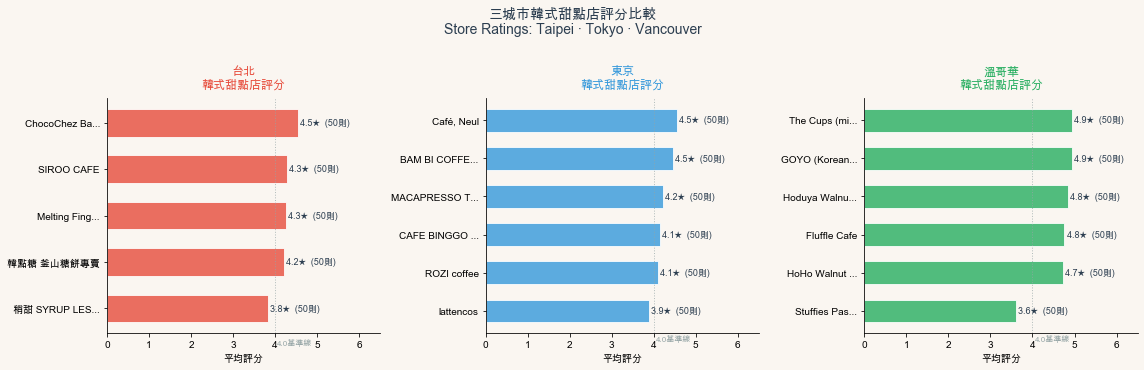

✅ 圖表 3 完成


In [5]:
# ── 各城市店家評分分布 ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#FAF6F1')

for ax, (city, df) in zip(axes, city_dfs.items()):
    ax.set_facecolor('#FAF6F1')
    color = CITY_COLORS[city]

    shop_stats = []
    for shop in df['店名'].unique():
        s = df[df['店名'] == shop]
        scores = pd.to_numeric(s['評分'], errors='coerce')
        shop_name = shop[:12] + ('...' if len(shop) > 12 else '')
        shop_stats.append({
            '店名': shop_name,
            '平均評分': scores.mean(),
            '評論數': len(s),
        })

    df_stat = pd.DataFrame(shop_stats).sort_values('平均評分')

    bars = ax.barh(df_stat['店名'], df_stat['平均評分'],
                   color=color, alpha=0.8, height=0.6,
                   edgecolor='white', linewidth=1)

    # 評論數標籤
    for bar, (_, row) in zip(bars, df_stat.iterrows()):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f"{row['平均評分']:.1f}★  ({int(row['評論數'])}則)",
                va='center', fontsize=9, color=COLORS['dark'])

    ax.set_xlim(0, 6.5)
    ax.set_xlabel('平均評分', fontsize=10)
    ax.set_title(f'{city}\n韓式甜點店評分', fontsize=12,
                 fontweight='bold', color=color, pad=10)
    ax.axvline(x=4.0, color=COLORS['gray'], linewidth=1,
               linestyle=':', alpha=0.7)
    ax.text(4.05, -0.8, '4.0基準線', fontsize=8, color=COLORS['gray'])
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('三城市韓式甜點店評分比較\nStore Ratings: Taipei · Tokyo · Vancouver',
             fontsize=14, fontweight='bold', color=COLORS['dark'], y=1.02)
plt.tight_layout()
plt.savefig('chart_03_city_ratings.png', dpi=150, bbox_inches='tight',
            facecolor='#FAF6F1')
plt.show()
print('✅ 圖表 3 完成')

### 2-3 跨店關鍵字熱度：三城市比較

> **判讀說明**：顏色深淺代表「出現在幾間不同的店」，而非總次數。出現店數越多，代表消費者自發需求越廣泛。

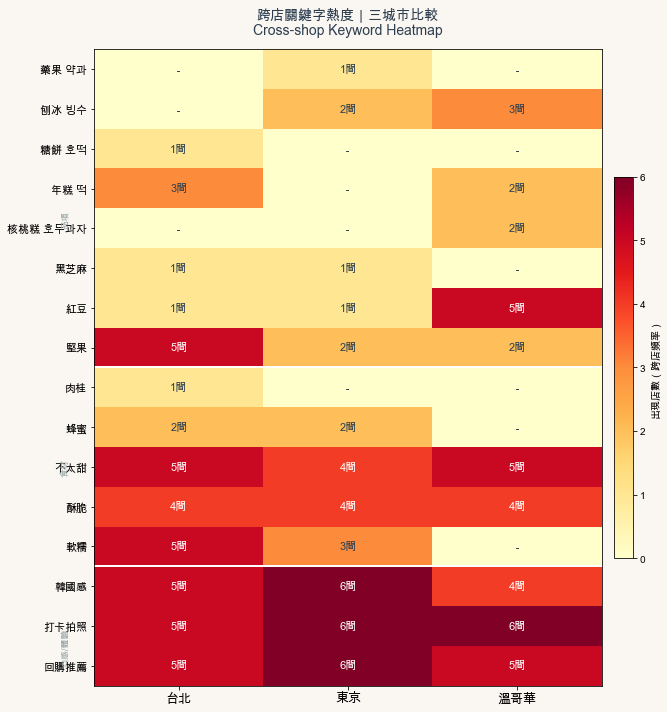

✅ 圖表 4 完成


In [6]:
# ── 跨店關鍵字熱力圖 ──────────────────────────────
cities = list(city_cross.keys())
labels = list(KEYWORDS.keys())

# 建立矩陣（出現店數）
matrix = []
for label in labels:
    row = [city_cross[c].get(label, {}).get('shop_num', 0) for c in cities]
    matrix.append(row)

df_heat = pd.DataFrame(matrix, index=labels, columns=cities)

# 只保留至少在一個城市出現的
df_heat = df_heat[df_heat.sum(axis=1) > 0]

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('#FAF6F1')
ax.set_facecolor('#FAF6F1')

# 熱力圖
max_shops = 6
im = ax.imshow(df_heat.values, cmap='YlOrRd',
               aspect='auto', vmin=0, vmax=max_shops)

# 數值標籤
for i in range(len(df_heat)):
    for j in range(len(cities)):
        val = df_heat.values[i, j]
        text_color = 'white' if val >= 4 else COLORS['dark']
        display = f'{int(val)}間' if val > 0 else '－'
        ax.text(j, i, display, ha='center', va='center',
                fontsize=11, color=text_color, fontweight='bold')

ax.set_xticks(range(len(cities)))
ax.set_xticklabels(cities, fontsize=13, fontweight='bold')
ax.set_yticks(range(len(df_heat)))
ax.set_yticklabels(df_heat.index, fontsize=11)

# 分隔線區分品項類型
ax.axhline(y=7.5, color='white', linewidth=2)
ax.axhline(y=12.5, color='white', linewidth=2)

# 分類標籤
ax.text(-0.7, 3.75, '品項', fontsize=9, color=COLORS['gray'],
        rotation=90, va='center')
ax.text(-0.7, 10, '食材', fontsize=9, color=COLORS['gray'],
        rotation=90, va='center')
ax.text(-0.7, 14.5, '口感/體驗', fontsize=9, color=COLORS['gray'],
        rotation=90, va='center')

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('出現店數（跨店頻率）', fontsize=10)

ax.set_title('跨店關鍵字熱度｜三城市比較\nCross-shop Keyword Heatmap',
             fontsize=14, fontweight='bold', pad=15, color=COLORS['dark'])

plt.tight_layout()
plt.savefig('chart_04_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#FAF6F1')
plt.show()
print('✅ 圖表 4 完成')

### 2-4 消費者口味偏好：三城市一致性分析

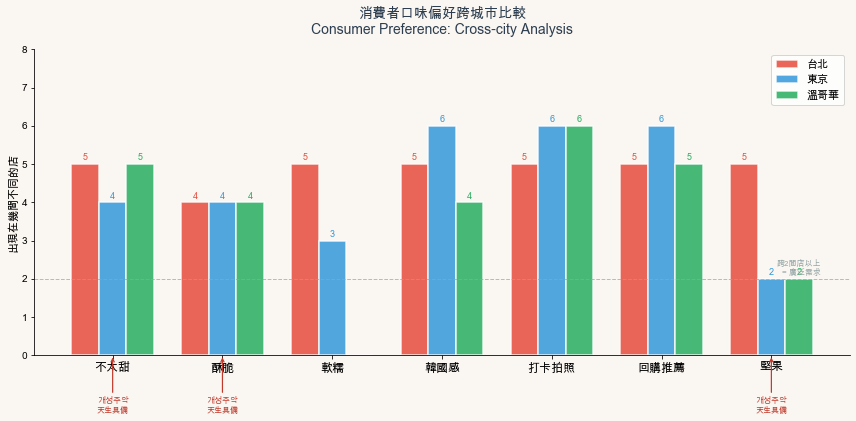

✅ 圖表 5 完成


In [7]:
# ── 口感/體驗關鍵字跨城市比較 ─────────────────────
experience_keys = ['不太甜', '酥脆', '軟糯', '韓國感', '打卡拍照', '回購推薦', '堅果']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAF6F1')
ax.set_facecolor('#FAF6F1')

x = np.arange(len(experience_keys))
width = 0.25

for i, (city, color) in enumerate(CITY_COLORS.items()):
    if city not in city_cross:
        continue
    vals = [city_cross[city].get(k, {}).get('shop_num', 0)
            for k in experience_keys]
    bars = ax.bar(x + i * width, vals, width,
                  label=city, color=color, alpha=0.85,
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    str(int(val)), ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color=color)

total_shops = 6
ax.axhline(y=2, color=COLORS['gray'], linewidth=1,
           linestyle='--', alpha=0.7)
ax.text(len(experience_keys) - 0.3, 2.1,
        '跨2間店以上\n= 廣泛需求',
        fontsize=8, color=COLORS['gray'], ha='right')

ax.set_xticks(x + width)
ax.set_xticklabels(experience_keys, fontsize=12, fontweight='bold')
ax.set_ylabel('出現在幾間不同的店', fontsize=11)
ax.set_ylim(0, 8)
ax.set_title('消費者口味偏好跨城市比較\nConsumer Preference: Cross-city Analysis',
             fontsize=14, fontweight='bold', pad=15, color=COLORS['dark'])
ax.legend(fontsize=11, framealpha=0.8, facecolor='white')

# 標注개성주악符合的項目
matched = ['不太甜', '酥脆', '堅果']
for key in matched:
    idx = experience_keys.index(key)
    ax.annotate('개성주악\n天生具備',
                xy=(idx + width, 0),
                xytext=(idx + width, -1.5),
                ha='center', fontsize=8, color=COLORS['red'],
                arrowprops=dict(arrowstyle='->', color=COLORS['red'],
                                lw=1.2),
                annotation_clip=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('chart_05_preference.png', dpi=150, bbox_inches='tight',
            facecolor='#FAF6F1')
plt.show()
print('✅ 圖表 5 完成')

---
## Stage 3：Cross-validation｜交叉比對與結論

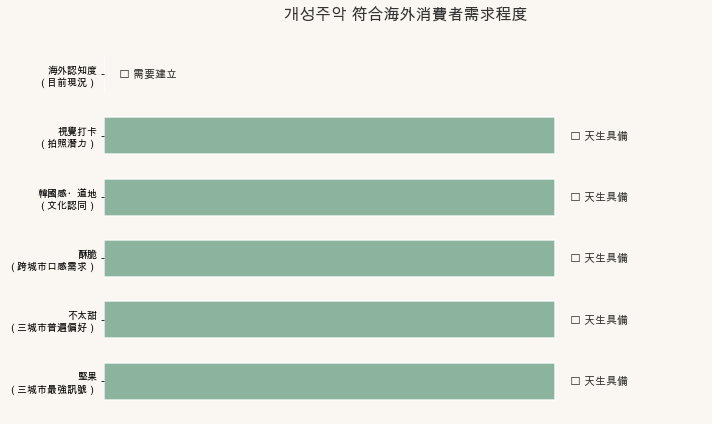

✅ 圖表 6 完成


In [21]:
import matplotlib.pyplot as plt

# 定義顏色
COLORS = {
    'green': '#78A890', 
    'red': '#D67272', 
    'dark': '#333333'
}

# 修改：將 figsize 調整為適合單張圖表的尺寸，並移除 1, 2 的參數
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FAF6F1')

# 設定背景
ax.set_facecolor('#FAF6F1')

criteria = ['堅果\n（三城市最強訊號）',
            '不太甜\n（三城市普遍偏好）',
            '酥脆\n（跨城市口感需求）',
            '韓國感・道地\n（文化認同）',
            '視覺打卡\n（拍照潛力）',
            '海外認知度\n（目前現況）']

match_score = [3, 3, 3, 3, 3, 0]
colors_bar = [COLORS['green'] if s > 0 else COLORS['red'] for s in match_score]
labels_bar = ['✅ 天生具備' if s > 0 else '❌ 需要建立' for s in match_score]

# 繪製圖表
bars = ax.barh(criteria, match_score, color=colors_bar,
                alpha=0.85, height=0.6, edgecolor='white', linewidth=1.5)

# 加入標籤
for bar, label in zip(bars, labels_bar):
    width = bar.get_width()
    ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             label, va='center', ha='left', fontsize=11, fontweight='bold', color=COLORS['dark'])

# 設定座標軸
ax.set_xlim(0, 4)
ax.set_title('개성주악 符合海外消費者需求程度', 
              fontsize=16, fontweight='bold', color=COLORS['dark'], pad=20)
ax.set_xticks([]) 

# 移除邊框
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# # 右圖：策略建議泡泡圖
# ax2 = axes[1]
# ax2.set_facecolor('#FAF6F1')

# strategies = [
#     {'label': '首爾\n인사동・북촌', 'risk': 2, 'opportunity': 9,
#      'size': 800, 'color': COLORS['green'], 'note': '推薦優先'},
#     {'label': '首爾\n홍대・성수동', 'risk': 4, 'opportunity': 7,
#      'size': 500, 'color': COLORS['blue'], 'note': '次要選項'},
#     {'label': '台北\n（海外第一站）', 'risk': 6, 'opportunity': 8,
#      'size': 400, 'color': COLORS['orange'], 'note': '中期目標'},
#     {'label': '東京', 'risk': 7, 'opportunity': 6,
#      'size': 300, 'color': COLORS['gray'], 'note': '長期目標'},
# ]

# for s in strategies:
#     ax2.scatter(s['risk'], s['opportunity'], s=s['size'],
#                 color=s['color'], alpha=0.75, edgecolors='white',
#                 linewidth=2, zorder=3)
#     ax2.annotate(s['label'],
#                  xy=(s['risk'], s['opportunity']),
#                  xytext=(s['risk'], s['opportunity'] + 0.6),
#                  ha='center', fontsize=9.5, fontweight='bold',
#                  color=s['color'])

# ax2.set_xlabel('市場教育成本（風險）→', fontsize=11)
# ax2.set_ylabel('市場機會潛力 →', fontsize=11)
# ax2.set_xlim(0, 11)
# ax2.set_ylim(4, 11)
# ax2.set_title('開店市場選擇策略\nMarket Entry Strategy',
#               fontsize=12, fontweight='bold',
#               color=COLORS['dark'], pad=10)
# ax2.axvline(x=5, color=COLORS['gray'], linewidth=1,
#             linestyle=':', alpha=0.5)
# ax2.axhline(y=7, color=COLORS['gray'], linewidth=1,
#             linestyle=':', alpha=0.5)
# ax2.text(1, 10.5, '低風險・高機會\n→ 優先進入', fontsize=8,
#          color=COLORS['green'], style='italic')

# for spine in ['top', 'right']:
#     ax2.spines[spine].set_visible(False)

# plt.suptitle('개성주악 市場可行性總結\nFeasibility Summary',
#              fontsize=14, fontweight='bold', color=COLORS['dark'], y=1.02)
# plt.tight_layout()
# plt.savefig('chart_06_summary.png', dpi=150, bbox_inches='tight',
#             facecolor='#FAF6F1')
# plt.show()
print('✅ 圖表 6 完成')

---
## Conclusions｜研究結論

### 개성주악 在首爾的市場可行性：**有機會，策略優先於海外**

| 面向 | 結論 |
|------|------|
| **品項特質** | ✅ 天生符合三城市消費者最在意的三個特質：堅果・不太甜・酥脆 |
| **首爾市場** | ✅ 연리희재已驗證存活可行性（2,069 則評論，口碑穩定） |
| **海外市場** | ⚠️ 三城市評論中完全未出現，認知度為零，海外擴張需做市場教育 |
| **競爭態勢** | ✅ 首爾幾乎無直接競爭者，先進者優勢強 |
| **製作難度** | ⚠️ 比藥果複雜，SOP 建立需要更多時間與測試 |

### 策略建議
1. **首爾優先**，選址인사동・북촌等傳統文化商圈，客群本身對傳統甜點有高接受度
2. **菜單策略**：약과帶客流，개성주악建品牌壁壘
3. **海外擴張**：等首爾品牌建立後，以台北作為第一個海外試點

---

## What I Learned｜研究心得

**1. 數據收集：繞路比硬攻有效**
Naver Map 反爬機制讓我踩了很多坑（Selenium、API 都被擋），最終改用 Apify。這個決策讓我學到：工程選擇不只是技術問題，也是時間資源的分配判斷。

**2. 發現自己的偏差，比從一開始就做對更重要**
跨店關鍵字的修正，是在發現單店數據失真後主動調整的。好的分析師不是不犯錯，而是能在結論出來前發現並修正錯誤。

**3. 正確的問題框架比更多數據重要**
「哪個品項最多人提到」和「哪個品項被最多不同類型消費者自發提到」，問題只差幾個字，但答案完全不同。

---
*Anita Wu · 2026 年 4 月 · Python · Apify · Claude AI（分析輔助）*